### Imports libraries

In [1]:
from util import get_data_merged, get_data_frames, alert_end

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import pickle

from scipy import stats
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.decomposition import PCA
from joblib import dump, load

### Data processing

In [11]:
data_log, data_dash = get_data_frames()
features, labels = get_data_merged(data_log, data_dash)
features = features.drop(columns=["timestamp"])

### Models

In [12]:
def normalized_mae(true_values, predicted_values):
    mae_value = mean_absolute_error(true_values, predicted_values)
    nmae_value = mae_value / np.mean(true_values)
    return nmae_value

In [6]:
def train_random_forest_randomsearch(features: pd.DataFrame, labels: pd.Series):
    X_train, X_val, y_train, y_val = train_test_split(
        features,
        np.ravel(labels),
        test_size=0.20,
        random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    rf_model = RandomForestRegressor(random_state=42, n_jobs=2)

    nmae_scorer = make_scorer(normalized_mae, greater_is_better=False)

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    param_dist = {
        'n_estimators': [50, 100, 150],
        'max_features': ['log2', 'sqrt'],
        'max_depth': [20, 30, 50, 60, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'bootstrap': [True, False]
    }

    random_search = RandomizedSearchCV(
        estimator=rf_model,
        param_distributions=param_dist,
        scoring=nmae_scorer,
        cv=kfold,
        n_iter=20, 
        verbose=3,
        n_jobs=1,
        random_state=42
    )

    random_search.fit(X_train_scaled, y_train)

    best_model = random_search.best_estimator_
    best_params = random_search.best_params_

    y_pred = best_model.predict(X_val_scaled)
    mae_value = mean_absolute_error(y_val, y_pred)
    nmae_value = normalized_mae(y_val, y_pred)

    return mae_value, nmae_value, best_model, best_params, X_val_scaled, y_val

In [7]:
def train_xgboost_randomsearch(features: pd.DataFrame, labels: pd.Series):
    X_train, X_val, y_train, y_val = train_test_split(
        features,
        np.ravel(labels),
        test_size=0.20,
        random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=2)

    nmae_scorer = make_scorer(normalized_mae, greater_is_better=False)

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    param_dist = {
        'n_estimators': [150, 300, 450],
        'max_depth': [10, 15, 25],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.6, 0.8, 1.0],
    }

    random_search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_dist,
        scoring=nmae_scorer,
        cv=kfold,
        n_iter=20, 
        verbose=3,
        n_jobs=1,
        random_state=42
    )

    random_search.fit(X_train_scaled, y_train)

    best_model = random_search.best_estimator_
    best_params = random_search.best_params_

    y_pred = best_model.predict(X_val_scaled)
    mae_value = mean_absolute_error(y_val, y_pred)
    nmae_value = normalized_mae(y_val, y_pred)

    return mae_value, nmae_value, best_model, best_params, X_val_scaled, y_val

In [25]:
def train_xgb_model(data, answer):
    X_train, X_validation, y_train, y_validation = train_test_split(
        data,
        np.ravel(answer),
        test_size=0.20,
        random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_validation_scaled = scaler.transform(X_validation)

    xgb_model = XGBRegressor(
        n_estimators=800,
        learning_rate=0.01,  
        max_depth=50, 
        n_jobs=3,
        random_state=42,
        verbose=3
    )

    mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    cv_scores = cross_val_score(
        xgb_model,
        X_train_scaled,
        y_train,
        cv=kf,
        scoring=mae_scorer
    )
    avg_cv_score = np.mean(cv_scores)

    xgb_model.fit(
        X_train_scaled,
        y_train,
        eval_set=[(X_validation_scaled, y_validation)],
        verbose=True
    )

    y_pred = xgb_model.predict(X_validation_scaled)
    mae = mean_absolute_error(y_validation, y_pred)
    nmae = mae / np.mean(y_validation)

    feature_importances = xgb_model.feature_importances_
   

    return mae, nmae, xgb_model

In [19]:
def train_random_forest_kfold(features: pd.DataFrame, labels: pd.Series):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mae_values = []
    nmae_values = []
    models = []
    
    for train_index, val_index in kf.split(features):
        X_train, X_val = features.iloc[train_index], features.iloc[val_index]
        y_train, y_val = labels.iloc[train_index], labels.iloc[val_index]
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        rf_model = RandomForestRegressor(
            random_state=42,
            n_estimators=100,
            max_features='sqrt',
            max_depth=64,
            min_samples_split=2,
            min_samples_leaf=1,
            bootstrap=True,
            verbose=3,
            n_jobs=2
        )

        rf_model.fit(X_train_scaled, y_train)

        y_pred = rf_model.predict(X_val_scaled)
        mae_value = mean_absolute_error(y_val, y_pred)
        nmae_value = normalized_mae(y_val, y_pred)

        mae_values.append(mae_value)
        nmae_values.append(nmae_value)
        models.append(rf_model)

    return np.mean(mae_values), np.mean(nmae_values), models[-1]

In [ ]:
def train_random_forest(features: pd.DataFrame, labels: pd.Series):
    X_train, X_val, y_train, y_val = train_test_split(features, labels, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    rf_model = RandomForestRegressor(
        random_state=42,
        n_estimators=100,
        max_features='sqrt',
        max_depth=64,
        min_samples_split=2,
        min_samples_leaf=1,
        bootstrap=True,
        verbose=3,
        n_jobs=2
    )

    rf_model.fit(X_train_scaled, y_train)

    y_pred = rf_model.predict(X_val_scaled)

    mae_value = mean_absolute_error(y_val, y_pred)
    nmae_value = normalized_mae(y_val, y_pred)

    return mae_value, nmae_value, rf_model

In [14]:
def train_rf_model(features_train: pd.DataFrame, labels_train: pd.Series):
    X_train, X_validation, y_train, y_validation = train_test_split(
        features_train,
        np.ravel(labels_train),
        test_size=0.20,
        random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_validation_scaled = scaler.transform(X_validation)

    rf_model = RandomForestRegressor(
        n_estimators=80,
        max_depth=64,
        min_samples_split=4,
        min_samples_leaf=2,
        bootstrap=False,
        verbose=1,
        max_features='sqrt',
        n_jobs=2,
        random_state=42
    )

    mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    cv_scores = cross_val_score(
        rf_model,
        X_train_scaled,
        y_train,
        cv=kf,
        scoring=mae_scorer
    )

    avg_cv_score = np.mean(cv_scores)

    rf_model.fit(X_train_scaled, y_train)

    y_pred_rf = rf_model.predict(X_validation_scaled)
    mae_rf = mean_absolute_error(y_validation, y_pred_rf)
    nmae_rf = mae_rf / np.mean(y_validation)

    feature_importances = rf_model.feature_importances_
    print(feature_importances)

    return mae_rf, nmae_rf, rf_model

### Train models

In [ ]:
rf_mae, rf_nmae, rf_best_model, rf_best_params, rf_X_val_scaled, rf_y_val = train_random_forest_randomsearch(features, labels)
rf_y_pred = best_model.predict(rf_X_val_scaled)
visualize_results(rf_y_val, rf_y_pred, rf_best_params, rf_features.columns)
alert_end()

In [ ]:
xgb_mae, xgb_nmae, xgb_best_model, xgb_best_params, xgb_X_val_scaled, xgb_y_val = train_xgboost_randomsearch(features, labels)
xgb_y_pred = best_model.predict(xgb_X_val_scaled)
visualize_results(xgb_y_val, xgb_y_pred, xgb_best_params, features.columns)
alert_end()

In [26]:
xgb_mae, xgb_nmae, xgb_best_model = train_xgb_model(features, labels)
print(f"{xgb_nmae*100}%")
visualize_results(xgb_best_model.feature_importances_, features.columns)
alert_end()

/home/kilmer/Development/data-science/search-telemetry-service-estimation/.env/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [22:13:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "verbose" } are not used.

  warnings.warn(smsg, UserWarning)


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  1.6min
[Parallel(n_jobs=2)]: Done  80 out of  80 | elapsed:  2.9min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.9s
[Parallel(n_jobs=2)]: Done  80 out of  80 | elapsed:    1.5s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  1.6min
[Parallel(n_jobs=2)]: Done  80 out of  80 | elapsed:  2.9min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.0s
[Parallel(n_jobs=2)]: Done  80 out of  80 | elapsed:    1.5s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:  1.7min
[Parallel(n_job

[0.12087179 0.12097361 0.0845484  0.00015544 0.00323894 0.0001652
 0.12157127 0.11548116 0.08945199 0.00071016 0.00312446 0.00051422
 0.12340169 0.12145446 0.08946801 0.00093687 0.00323114 0.00070117]
3.896516955854798%


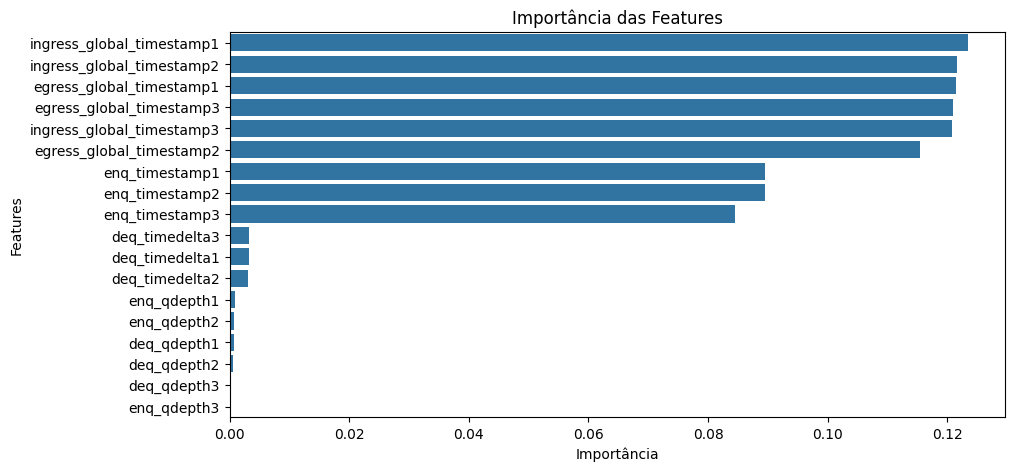

/home/kilmer/Development/data-science/search-telemetry-service-estimation/.env/lib/python3.12/site-packages/plyer/platforms/linux/notification.py:103: UserWarning: The Python dbus package is not installed.
Try installing it with your distribution's package manager, it is usually called python-dbus or python3-dbus, but you might have to try dbus-python instead, e.g. when using pip.
  warnings.warn(msg)


In [15]:
rf_mae, rf_nmae, rf_best_model = train_rf_model(features, labels)
print(f"{rf_nmae*100}%")
visualize_results(rf_best_model.feature_importances_, features.columns)
alert_end()

In [ ]:
rf_mae, rf_nmae, rf_best_model, y_val = train_random_forest(features, labels)
print(f"{rf_nmae*100}%")
rf_y_pred = rf_best_model.predict(rf_X_val_scaled)
visualize_results(rf_y_val, rf_y_pred, rf_best_model.feature_importances_, features.columns)
alert_end()

### Visualize

In [10]:
def visualize_results_random_search(feature_importances, feature_names):

    feature_importances_df = pd.DataFrame({
        'Features': feature_names,
        'Importância': feature_importances
    }).sort_values(by='Importância', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importância', y='Features', data=feature_importances_df)
    plt.title('Importância das Features')
    plt.xlabel('Importância')
    plt.ylabel('Features')
    plt.show()

In [9]:
def visualize_results(feature_importances, feature_names):

    feature_importances_df = pd.DataFrame({
        'Features': feature_names,
        'Importância': feature_importances
    }).sort_values(by='Importância', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importância', y='Features', data=feature_importances_df)
    plt.title('Importância das Features')
    plt.xlabel('Importância')
    plt.ylabel('Features')
    plt.show()

In [4]:

data_log_sinusoid = pd.read_csv("datasets/log_INT_sinusoid_8h.txt", delimiter=",")
data_log_sinusoid.columns = data_log_sinusoid.columns.str.replace(" ", "")
data_log_flashcrowd = pd.read_csv("datasets/log_INT_flashcrowd_6h.txt", delimiter=",")
data_log_flashcrowd.columns = data_log_flashcrowd.columns.str.replace(" ", "")
data_log_mix = pd.read_csv("datasets/log_INT_mix_5h.txt", delimiter=",")
data_log_mix.columns = data_log_mix.columns.str.replace(" ", "")

data_dash_sinusoid = pd.read_csv("datasets/dash_sinusoid_8h.log", sep=",")
data_dash_flashcrowd = pd.read_csv("datasets/dash_flashcrowd_6h.log", sep=",")
data_dash_mix = pd.read_csv("datasets/dash_mix_5h.log", sep=",")



def get_data_merged(data_log : pd.DataFrame, data_dash : pd.DataFrame):
    for colum in data_log.columns:
        if(data_log[colum].std() == 0.0):
            data_log = data_log.drop(columns=[colum])
    result_total = pd.merge(data_log, data_dash, on='timestamp', how='left')
    result_total = result_total.fillna(result_total.mean())
    z_scores = np.abs(stats.zscore(result_total['framesDisplayedCalc']))
    threshold = 4
    result_total = result_total[(z_scores < threshold)]
    labels = result_total['framesDisplayedCalc']

    columns_to_remove = list(data_dash.columns)
    columns_to_remove.remove('timestamp')
    result_total = result_total.drop(columns=columns_to_remove)
    
    return result_total, labels

NMAE Sinusoid: 0.0341
NMAE Flashcrowd: 0.1289
NMAE Mix: 0.1393


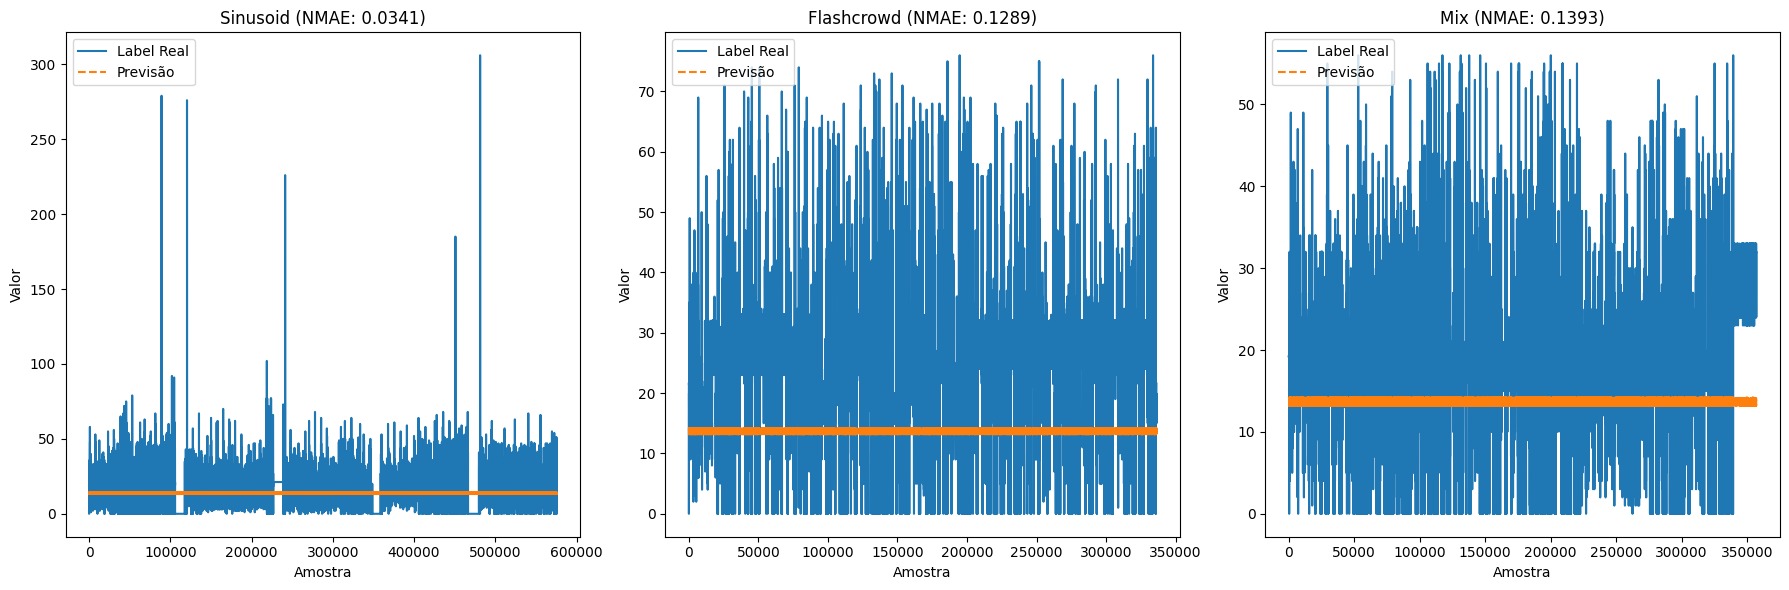

In [19]:
feature_sinusoid, label_sinusoid = get_data_merged(data_log_sinusoid,data_dash_sinusoid)
feature_flashcrowd, label_flashcrowd = get_data_merged(data_log_flashcrowd ,data_dash_flashcrowd)
feature_mix, label_mix = get_data_merged(data_log_mix,data_dash_mix)
feature_sinusoid = feature_sinusoid.drop(columns=["timestamp"])
feature_flashcrowd = feature_flashcrowd.drop(columns=["timestamp"])
feature_mix = feature_mix.drop(columns=["timestamp"])


def calculate_nmae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred)) / (np.max(y_true) - np.min(y_true))



nmae_sinusoid = calculate_nmae(label_sinusoid, pred_sinusoid)
nmae_flashcrowd = calculate_nmae(label_flashcrowd, pred_flashcrowd)
nmae_mix = calculate_nmae(label_mix, pred_mix)

print(f"NMAE Sinusoid: {nmae_sinusoid:.4f}")
print(f"NMAE Flashcrowd: {nmae_flashcrowd:.4f}")
print(f"NMAE Mix: {nmae_mix:.4f}")

plt.figure(figsize=(18, 6))


plt.subplot(1, 3, 1)
plt.plot(np.arange(len(label_sinusoid)), label_sinusoid, label="Label Real")
plt.plot(np.arange(len(pred_sinusoid)), pred_sinusoid, label="Previsão", linestyle='--')
plt.title(f"Sinusoid (NMAE: {nmae_sinusoid:.4f})")
plt.xlabel("Amostra")
plt.ylabel("Valor")
plt.legend()

# Gráfico para Flashcrowd
plt.subplot(1, 3, 2)
plt.plot(np.arange(len(label_flashcrowd)), label_flashcrowd, label="Label Real")
plt.plot(np.arange(len(pred_flashcrowd)), pred_flashcrowd, label="Previsão", linestyle='--')
plt.title(f"Flashcrowd (NMAE: {nmae_flashcrowd:.4f})")
plt.xlabel("Amostra")
plt.ylabel("Valor")
plt.legend()

# Gráfico para Mix
plt.subplot(1, 3, 3)
plt.plot(np.arange(len(label_mix)), label_mix, label="Label Real")
plt.plot(np.arange(len(pred_mix)), pred_mix, label="Previsão", linestyle='--')
plt.title(f"Mix (NMAE: {nmae_mix:.4f})")
plt.xlabel("Amostra")
plt.ylabel("Valor")
plt.legend()

plt.tight_layout()
plt.show()

